As CD-HIT dereplication was performed in a 2-step process (global 99% ANI followed by 95% ANI over 85% coverage), hybrid and short-read representative sequences dereplicated at 99% ANI were combined and dereplicated at 95% ANI over 85% coverage to form shared vOTUs.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('../data/hybrid_vs_shortread_comparison/shared_hybrid_shortread_votu-info.tsv', sep='\t')

"**2× reduction** in vOTU recovery based on short-read viral contigs"

In [2]:
len(df[df.num_hyb > 0])/len(df[df.num_sr > 0])

1.9750129466597617

"among shared vOTUs (n=11,098), long-read–based contigs were notably longer (**>2.4× median length**)"

In [3]:
df_both = df.loc[(df.num_hyb > 0) & (df.num_sr > 0)]

df_both_hyb = df_both[['votu95_id','max_hyb_len']].rename(columns={'max_hyb_len': 'max_len'})
df_both_hyb['type'] = 'hyb'

df_both_sr = df_both[['votu95_id','max_sr_len']].rename(columns={'max_sr_len': 'max_len'})
df_both_sr['type'] = 'sr'

df_comb = pd.concat([df_both_hyb, df_both_sr])

In [4]:
median_max_hyb_len = df_comb.loc[df_comb.type == 'hyb'].max_len.median()
median_max_sr_len = df_comb.loc[df_comb.type == 'sr'].max_len.median()

median_max_hyb_len, median_max_sr_len, median_max_hyb_len/median_max_sr_len

(np.float64(24697.0), np.float64(10165.0), np.float64(2.429611411706837))

### Supplementary Fig. 3A: Venn diagram of shared vOTUs formed from hybrid and short-read sequences

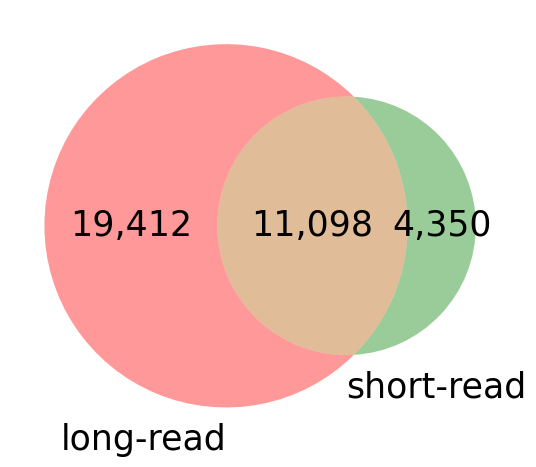

In [5]:
from matplotlib_venn import venn2

fs=25

x = {'both': len(df.loc[(df.num_hyb > 0) & (df.num_sr > 0)]),
     'long-read only': len(df.loc[(df.num_hyb > 0) & (df.num_sr == 0)]),
     'short-read only': len(df.loc[(df.num_hyb == 0) & (df.num_sr > 0)])}

v2 = venn2(subsets = (x['long-read only'], x['short-read only'], x['both']), set_labels = ('long-read', 'short-read'))

for text in v2.set_labels:
    text.set_fontsize(fs)
    
for text in v2.subset_labels:
    text.set_text(f"{int(text.get_text()):,}")
    text.set_fontsize(fs)

plt.tight_layout()
plt.show()

### Supplementary Fig. 3B: distributions of longest hybrid and short-read sequences in shared vOTUs containing both

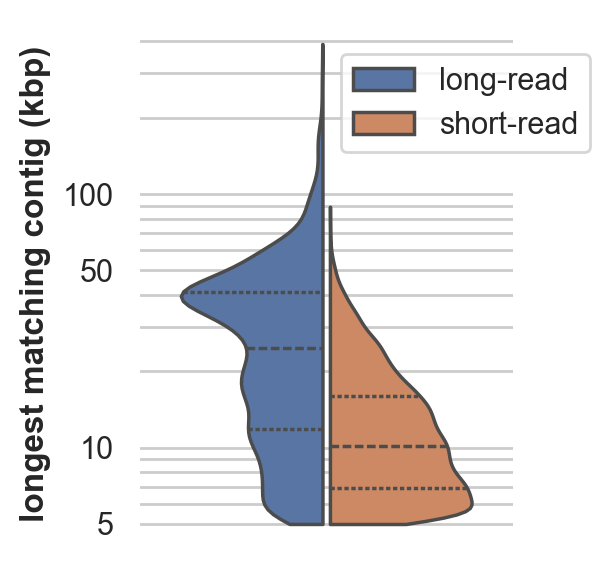

In [6]:
df_comb['x'] = ''

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(3, 3), dpi=200)

g = sns.violinplot(data=df_comb, y='max_len', x='x', hue='type', cut=0, ax=ax, split=True, gap=0.05, inner='quart', log_scale=True)

yticks = [*np.arange(5e3,11e3,1e3),*np.arange(2e4,11e4,1e4),*np.arange(2e5,5e5,1e5)]
g.set_yticks(yticks)
labels = [str(int(tick / 1e3)) if tick in [5e3, 10e3, 50e3, 100e3] else "" for tick in yticks]
ax.set_yticklabels(labels)

ax.set_ylabel('longest matching contig (kbp)', fontweight='bold')
ax.set_xlabel('')

handles, previous_labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=['long-read','short-read'], title='', loc=(0.54,0.75))

sns.despine(left=True, bottom=True)
plt.tight_layout()

### Supplementary Fig. 3C: % of hybrid sequences covered by short reads

Preprocessing steps:
1) Hybrid sequences at least twice as long as the longest short-read sequence in the shared vOTU, and assembled from the same sample, were extracted.
2) Short reads from that sample were mapped to the hybrid sequences using BWA-MEM.
3) Secondary alignments were removed, and properly paired reads mapping at 99% ANI over 80% of the read length were retained.
4) `samtools coverage` was run to estimate coverage statistics for each hybrid sequence.

In [7]:
df_coverage = pd.read_csv('../data/hybrid_vs_shortread_comparison/hybrid_sequence_shortread_mapping_coverage.tsv', sep='\t')

"these contigs were well covered by short reads (**median coverage of 99.6%**)"

In [8]:
df_coverage.coverage.describe()

count    3911.000000
mean       97.165695
std         6.542840
min        37.702100
25%        97.512300
50%        99.640800
75%       100.000000
max       100.000000
Name: coverage, dtype: float64

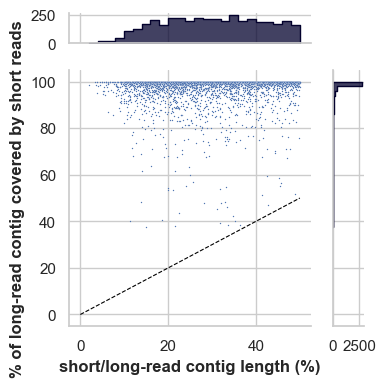

In [9]:
df_coverage['sr_hyb_perc'] = df_coverage.seq_len_sr/df_coverage.seq_len_hyb*100

g = sns.JointGrid(data=df_coverage, x='sr_hyb_perc', y='coverage', height=4, marginal_ticks=True)

g.plot_joint(sns.scatterplot, s=1)
g.plot_marginals(sns.histplot, element="step", color="#03012d", binwidth=2)

g.set_axis_labels('short/long-read contig length (%)', '% of long-read contig covered by short reads', fontweight='bold')

g.ax_joint.plot([0, 50], [0, 50], linestyle='--', color='black', linewidth=0.8)

sns.despine()
plt.tight_layout()